<a href="https://colab.research.google.com/github/shahdelmasry12/University-Machine-Learning-Project/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **About Dataset**


*   This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases.
*  The objective of the dataset is to diagnostically predict whether or not a patient has diabetes.
*   The datasets consists of several medical predictor variables and one target variable.
                                              
*   Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age	,BloodPressure	,SkinThickness,Glucose	,	DiabetesPedigreeFunction	,Outcome                                              

# **Imports**

In [19]:
#Imports
import numpy as np#Arrays
import pandas as pd#DataFrame,processing cleaning
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns #Visulization
#Machine Learning
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# **Load data**

In [20]:
df = pd.read_csv("https://raw.githubusercontent.com/shahdelmasry12/University-Machine-Learning-Project/refs/heads/main/diabetes_dataset.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Explore and Clean data**

In [21]:
df.shape

(768, 9)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [23]:
##Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [24]:
#Check Missing vallues
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [25]:
df.describe()#summery statistical about data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Handling Invalid Zero Values
   * Columns(	BloodPressure	,SkinThickness	Insulin	,BMI)  whose  Minimum values ​​equal 0


In [26]:
#Replace Zero to nan
cols_with_zero = ['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'SkinThickness']
for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)

In [27]:
#Check Missing vallues
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [28]:
#Fillna by medien
df=df.fillna(df.median())

In [29]:
df.describe()#summery statistical about data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [30]:
#Check Missing vallues
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


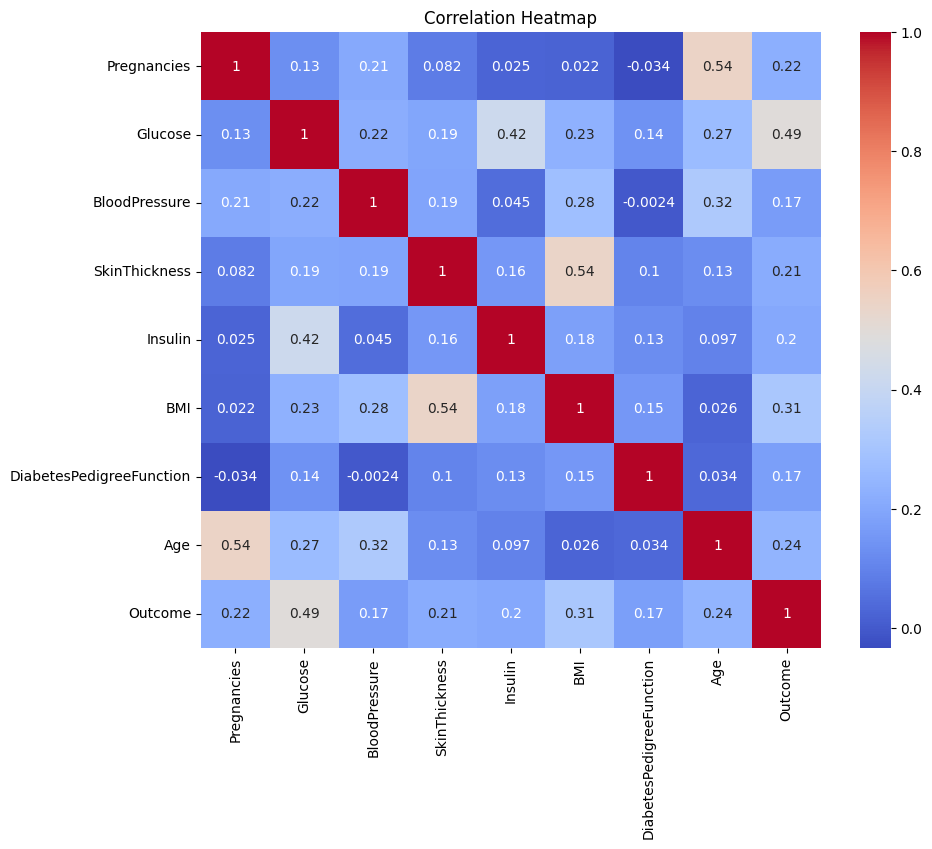

In [32]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# **Feature Engineering**

In [33]:
def add_all_features(df):
    df = df.copy()

    # 1. BMI × Age — الضغط التراكمي
    df['BMI_Age_Interaction'] = df['BMI'] * df['Age']

    # 2. نسبة السكر للإنسولين — مقاومة الإنسولين
    df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1)

    # 3. تصنيف BMI الطبي
    def bmi_category(x):
        if x < 18.5: return 0   # Underweight
        elif x < 25: return 1   # Normal
        elif x < 30: return 2   # Overweight
        else:        return 3   # Obese
    df['BMI_Category'] = df['BMI'].apply(bmi_category)

    # 4. علامة الخطر العمري
    df['High_Risk_Age'] = (df['Age'] > 45).astype(int)

    # 5. تصنيف السكر حسب معايير WHO
    def glucose_level(g):
        if g < 100:  return 0   # Normal
        elif g < 126: return 1  # Pre-diabetes
        else:         return 2  # Diabetes range
    df['Glucose_Level'] = df['Glucose'].apply(glucose_level)

    # 6. درجة الخطر المركّبة
    df['Composite_Risk'] = (
        df['Glucose'] / 200 +
        df['BMI']     / 50  +
        df['Age']     / 100
    )

    return df

In [35]:
df=add_all_features(df)

In [38]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age_Interaction,Glucose_Insulin_Ratio,BMI_Category,High_Risk_Age,Glucose_Level,Composite_Risk
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,1.174603,3,1,2,1.912
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,0.674603,2,0,0,1.267
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,1.452381,1,0,2,1.701
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,0.936842,2,0,0,1.217
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,0.810651,3,0,2,1.877


In [39]:
df.describe()#summery statistical about data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age_Interaction,Glucose_Insulin_Ratio,BMI_Category,High_Risk_Age,Glucose_Level,Composite_Risk
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958,1080.906771,1.054449,2.485677,0.153646,1.136719,1.589794
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951,437.813986,0.684436,0.739853,0.360844,0.786659,0.275594
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000,382.200000,0.206323,0.000000,0.000000,0.000000,0.972000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000,744.800000,0.746032,2.000000,0.000000,0.750000,1.387750
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000,987.250000,0.936508,3.000000,0.000000,1.000000,1.570000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000,1357.200000,1.175893,3.000000,0.000000,2.000000,1.788250
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000,2697.000000,12.000000,3.000000,1.000000,2.000000,2.375000


# **Vsulization(EDA)**